# VIX Event Detection and Multi-Wave Entry Strategy

> Methodology update, 2026-07-26: the event-strategy section now reconstructs the current month's VIX High on a point-in-time, month-to-date basis. A controlled comparison produced identical event dates and buy signals. The existing saved outputs are retained for continuity and will be regenerated during the reproducibility pass.

> The monthly chart below is a retrospective overview using finalized monthly High values. It is not the daily signal engine. Daily event decisions later in this notebook use 359 completed months plus the current month-to-date High.

> **Live-data notebook.** Run all cells from top to bottom. A single UTC run timestamp sets the exclusive end date for every VIX, SPY, and QQQ download; saved outputs represent the latest committed execution.


Notebook run timestamp (UTC): 2026-07-27T03:12:34.461016+00:00
===== Data Period =====
Daily start: 1990-01-02
Daily end  : 2026-07-24
Monthly start: 1990-01-31
Monthly end  : 2026-07-31
Monthly observations: 439

===== First 360M Baseline =====
First valid baseline month: 2019-12-31
Initial 360M Mean: 23.944583325915865
Initial 360M Std : 10.152317415115972
Initial +1σ: 34.09690074103184
Initial +2σ: 44.249218156147805

===== Latest Sigma Levels =====
Latest month: 2026-07-31
Monthly High VIX: 20.309999465942383
Mean 360: 26.040944422615897
+1σ: 37.21590909164545
+2σ: 48.39087376067501
Z-score: -0.5128378591259739

===== Months Above +2σ =====
            Monthly_High_VIX   Mean_360        +2σ   Z_score
Date                                                        
1997-10-31         48.639999  23.944583  44.249218  2.432491
1998-08-31         45.020000  23.944583  44.249218  2.075922
1998-09-30         48.060001  23.944583  44.249218  2.375361
1998-10-31         49.529999  23.944583  4

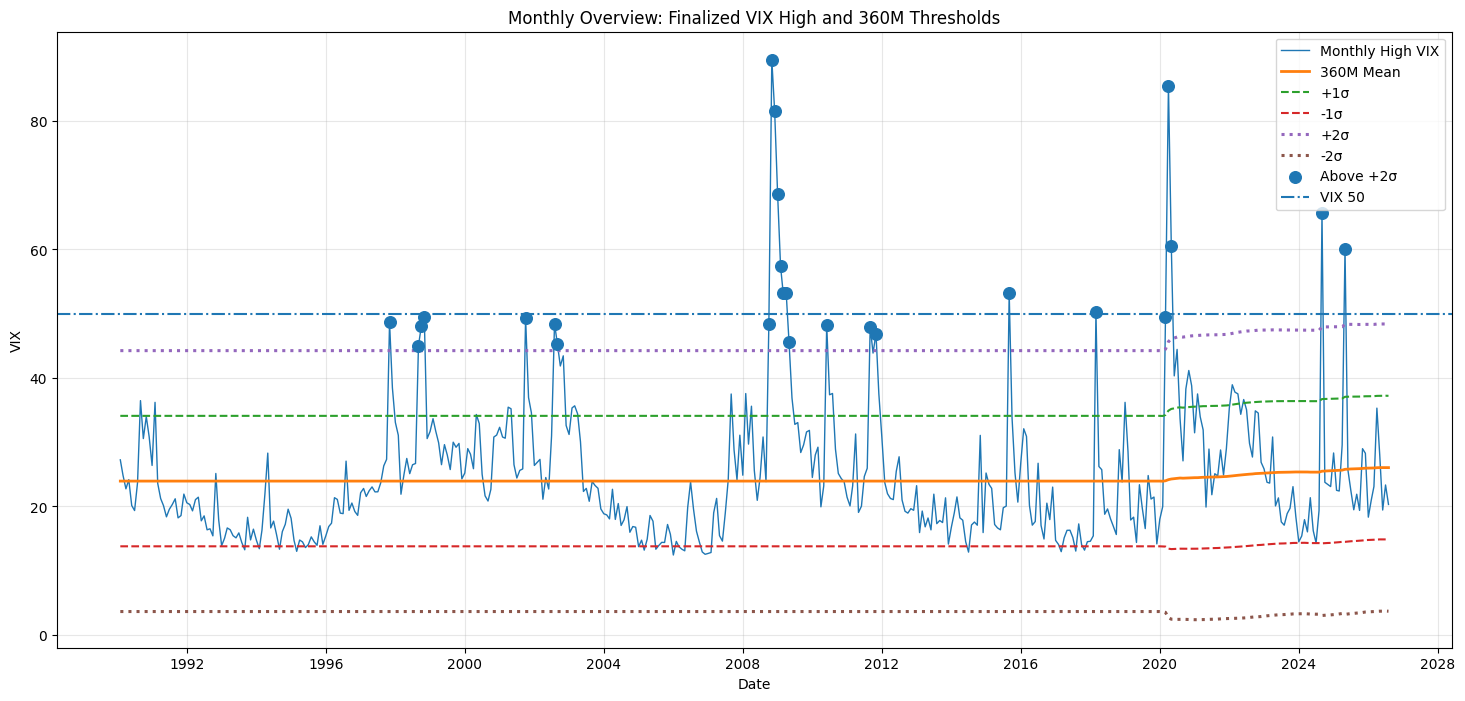

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RUN_TIMESTAMP_UTC = pd.Timestamp.now(tz="UTC")
LIVE_END_EXCLUSIVE = (
    RUN_TIMESTAMP_UTC.tz_localize(None).normalize() + pd.Timedelta(days=1)
).strftime("%Y-%m-%d")
print(f"Notebook run timestamp (UTC): {RUN_TIMESTAMP_UTC.isoformat()}")

# =========================
# VIX Monthly High +2 Sigma Spike Detection
# Raw VIX levels; no logarithmic transformation
#
# Objective:
# Use the longest available VIX history to identify months
# whose monthly High exceeds the 30-year (360-month) +2 sigma threshold.
#
# Early-history treatment:
# A full rolling baseline is unavailable during the first 360 months.
# The first complete 360-month baseline is applied retrospectively to that period.
# Beginning with month 361, the baseline updates as a standard 360-month roll.
# =========================

# =========================
# 1. Download data
# =========================

daily = yf.download(
    "^VIX",
    start="1990-01-01",
    end=LIVE_END_EXCLUSIVE,
    progress=False,
    auto_adjust=False,
)

# Flatten yfinance MultiIndex columns when present
if isinstance(daily.columns, pd.MultiIndex):
    daily.columns = daily.columns.get_level_values(0)

daily = daily[["High", "Close"]].dropna()
daily.columns = ["VIX_High", "VIX_Close"]

# =========================
# 2. Build monthly High series
# =========================

monthly = pd.DataFrame()
monthly["Monthly_High_VIX"] = daily["VIX_High"].resample("ME").max()
monthly["Monthly_Close_VIX"] = daily["VIX_Close"].resample("ME").last()
monthly = monthly.dropna()

# =========================
# 3. Calculate 360-month rolling mean and standard deviation
# =========================

window = 360

monthly["Mean_360_raw"] = monthly["Monthly_High_VIX"].rolling(window).mean()

# Use ddof=0 to match the population-standard-deviation convention.
# Pandas defaults to the sample-standard-deviation convention (ddof=1).
monthly["Std_360_raw"] = monthly["Monthly_High_VIX"].rolling(window).std(ddof=0)

monthly["+1σ_raw"] = monthly["Mean_360_raw"] + monthly["Std_360_raw"]
monthly["-1σ_raw"] = monthly["Mean_360_raw"] - monthly["Std_360_raw"]
monthly["+2σ_raw"] = monthly["Mean_360_raw"] + 2 * monthly["Std_360_raw"]
monthly["-2σ_raw"] = monthly["Mean_360_raw"] - 2 * monthly["Std_360_raw"]

# =========================
# 4. Apply the first complete baseline to early history
# =========================

first_valid_idx = monthly["Mean_360_raw"].first_valid_index()

first_mean = monthly.loc[first_valid_idx, "Mean_360_raw"]
first_std = monthly.loc[first_valid_idx, "Std_360_raw"]

monthly["Mean_360"] = monthly["Mean_360_raw"].copy()
monthly["Std_360"] = monthly["Std_360_raw"].copy()

monthly["+1σ"] = monthly["+1σ_raw"].copy()
monthly["-1σ"] = monthly["-1σ_raw"].copy()
monthly["+2σ"] = monthly["+2σ_raw"].copy()
monthly["-2σ"] = monthly["-2σ_raw"].copy()

# Backfill the pre-baseline period with the first complete 360-month reference.
pre_mask = monthly.index < first_valid_idx

monthly.loc[pre_mask, "Mean_360"] = first_mean
monthly.loc[pre_mask, "Std_360"] = first_std
monthly.loc[pre_mask, "+1σ"] = first_mean + first_std
monthly.loc[pre_mask, "-1σ"] = first_mean - first_std
monthly.loc[pre_mask, "+2σ"] = first_mean + 2 * first_std
monthly.loc[pre_mask, "-2σ"] = first_mean - 2 * first_std

# =========================
# 5. Identify months above +2 sigma
# =========================

monthly["Z_score"] = (
    monthly["Monthly_High_VIX"] - monthly["Mean_360"]
) / monthly["Std_360"]

monthly["Above_2sigma"] = monthly["Monthly_High_VIX"] > monthly["+2σ"]

spikes = monthly[monthly["Above_2sigma"]].copy()

# =========================
# 6. Group consecutive spike months into events
# =========================

spikes["New_Event"] = (
    spikes.index.to_series().diff().dt.days > 45
).fillna(True)

spikes["Event_ID"] = spikes["New_Event"].cumsum()

events = (
    spikes.groupby("Event_ID")
    .agg(
        Start_Date=("Monthly_High_VIX", lambda x: x.index[0].date()),
        End_Date=("Monthly_High_VIX", lambda x: x.index[-1].date()),
        Months=("Monthly_High_VIX", "count"),
        Max_VIX=("Monthly_High_VIX", "max"),
        Max_Z=("Z_score", "max"),
        Avg_2sigma_Level=("+2σ", "mean")
    )
    .reset_index(drop=True)
)

# =========================
# 7. Display results
# =========================

print("===== Data Period =====")
print("Daily start:", daily.index[0].date())
print("Daily end  :", daily.index[-1].date())
print("Monthly start:", monthly.index[0].date())
print("Monthly end  :", monthly.index[-1].date())
print("Monthly observations:", len(monthly))

print("\n===== First 360M Baseline =====")
print("First valid baseline month:", first_valid_idx.date())
print("Initial 360M Mean:", first_mean)
print("Initial 360M Std :", first_std)
print("Initial +1σ:", first_mean + first_std)
print("Initial +2σ:", first_mean + 2 * first_std)

print("\n===== Latest Sigma Levels =====")
latest = monthly.iloc[-1]
print("Latest month:", monthly.index[-1].date())
print("Monthly High VIX:", latest["Monthly_High_VIX"])
print("Mean 360:", latest["Mean_360"])
print("+1σ:", latest["+1σ"])
print("+2σ:", latest["+2σ"])
print("Z-score:", latest["Z_score"])

print("\n===== Months Above +2σ =====")
print(spikes[[
    "Monthly_High_VIX",
    "Mean_360",
    "+2σ",
    "Z_score"
]])

print("\n===== Spike Events =====")
print(events)

# Save CSV outputs
spikes.to_csv("vix_monthly_high_above_2sigma_months.csv")
events.to_csv("vix_monthly_high_above_2sigma_events.csv")

print("\nSaved files:")
print("vix_monthly_high_above_2sigma_months.csv")
print("vix_monthly_high_above_2sigma_events.csv")

# =========================
# 8. Plot the monthly overview
# =========================

plt.figure(figsize=(18, 8))

plt.plot(monthly.index, monthly["Monthly_High_VIX"], label="Monthly High VIX", linewidth=1)
plt.plot(monthly.index, monthly["Mean_360"], label="360M Mean", linewidth=2)

plt.plot(monthly.index, monthly["+1σ"], label="+1σ", linestyle="--", linewidth=1.5)
plt.plot(monthly.index, monthly["-1σ"], label="-1σ", linestyle="--", linewidth=1.5)

plt.plot(monthly.index, monthly["+2σ"], label="+2σ", linestyle=":", linewidth=2.2)
plt.plot(monthly.index, monthly["-2σ"], label="-2σ", linestyle=":", linewidth=2.2)

plt.scatter(
    spikes.index,
    spikes["Monthly_High_VIX"],
    label="Above +2σ",
    s=70,
    zorder=5
)

plt.axhline(50, linestyle="-.", linewidth=1.5, label="VIX 50")

plt.title("Monthly Overview: Finalized VIX High and 360M Thresholds")
plt.xlabel("Date")
plt.ylabel("VIX")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

===== VIX Data Period =====
Daily start: 1990-01-02
Daily end  : 2026-07-24
First valid 360M baseline: 2019-12-31
Initial +2σ: 44.249218156147805

===== VIX Crisis Events =====
    Event_ID Event_Start_Date Event_End_Date  Buy_Count Max_VIX_Date  \
0          1       1997-10-28     1997-12-01          1   1997-10-28   
1          2       1998-08-31     1998-11-05          2   1998-10-08   
2          3       2001-09-17     2001-11-15          1   2001-09-21   
3          4       2002-07-23     2002-08-28          1   2002-07-24   
4          5       2008-09-29     2009-05-21          2   2008-10-24   
5          6       2010-05-20     2010-06-23          1   2010-05-21   
6          7       2011-08-08     2011-12-09          2   2011-08-08   
7          8       2015-08-24     2015-09-10          1   2015-08-24   
8          9       2018-02-06     2018-02-26          1   2018-02-06   
9         10       2020-02-28     2020-05-29          2   2020-03-18   
10        11       2024-08-05  

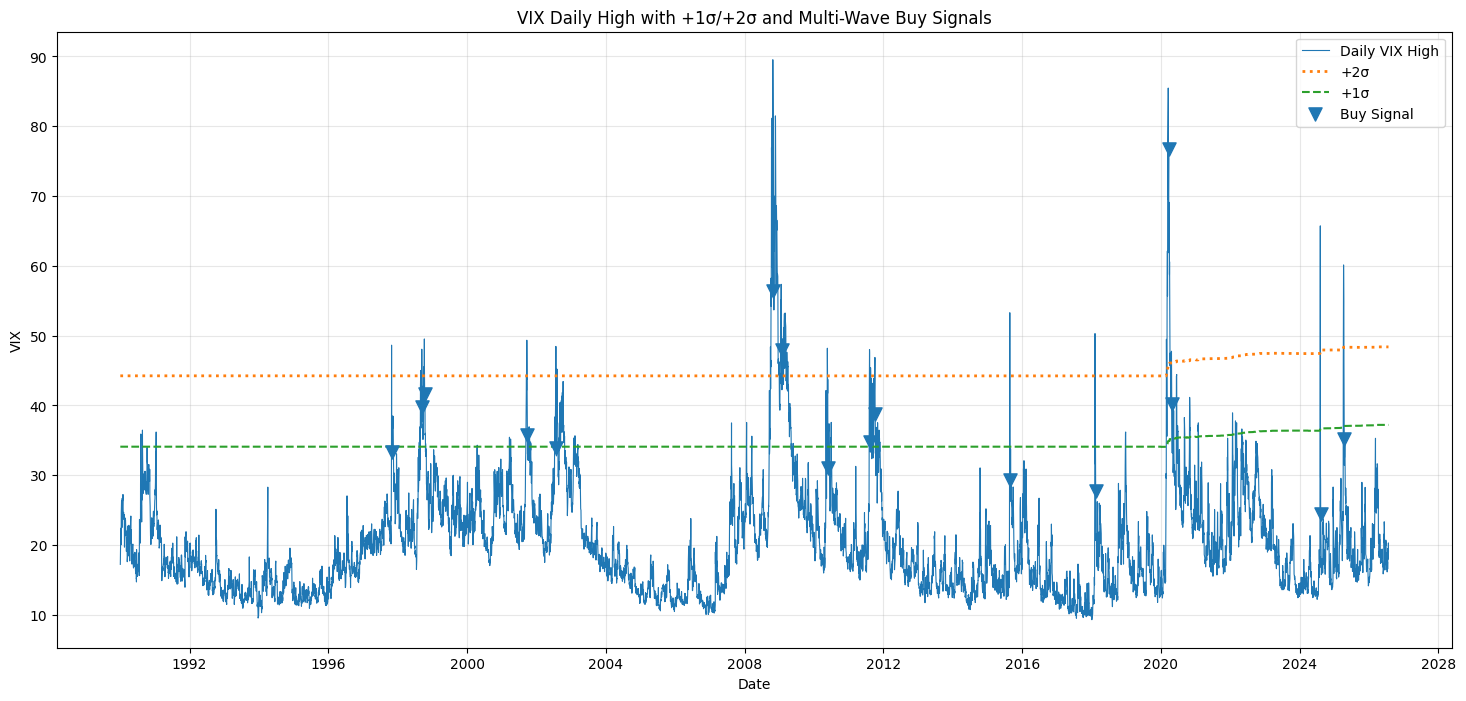

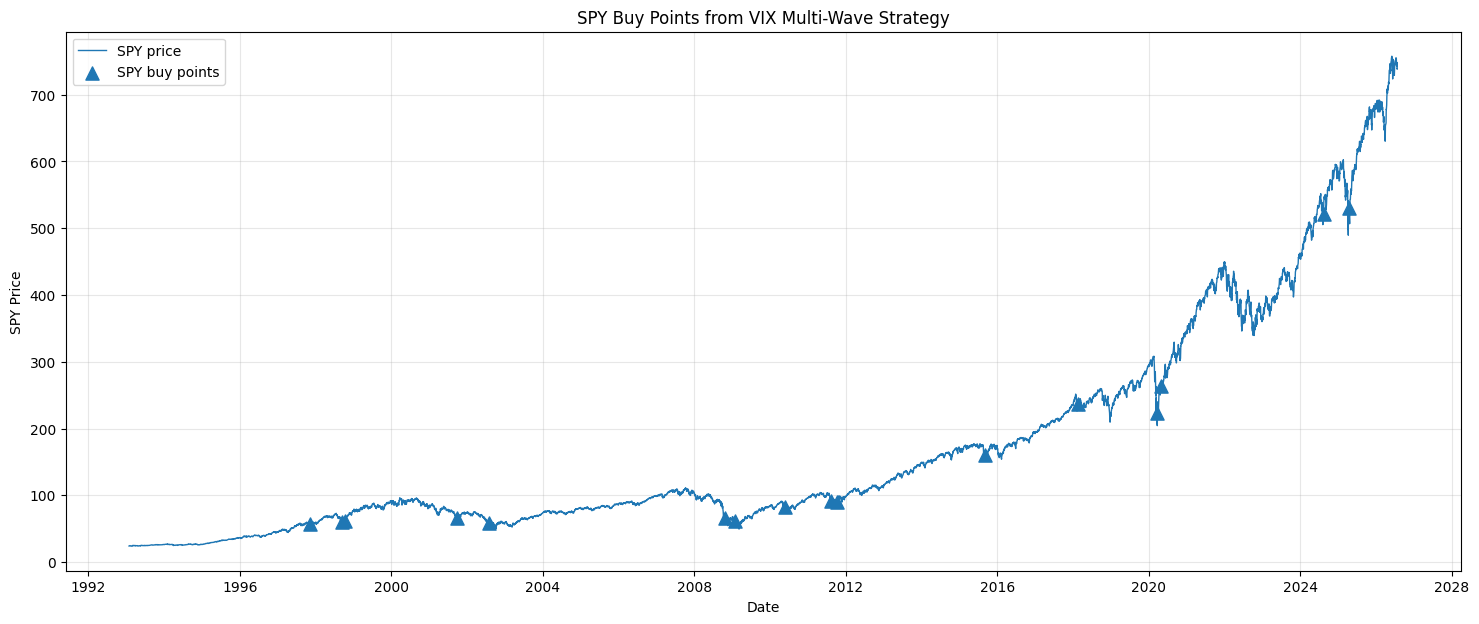

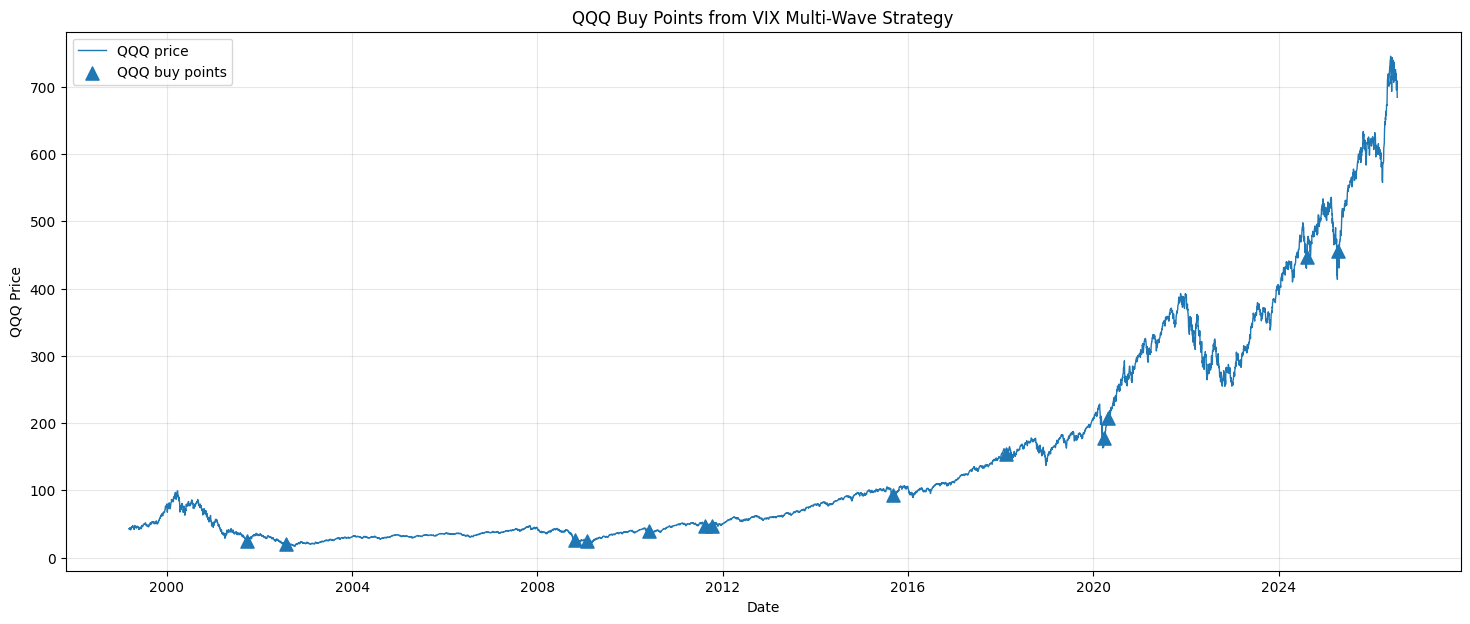

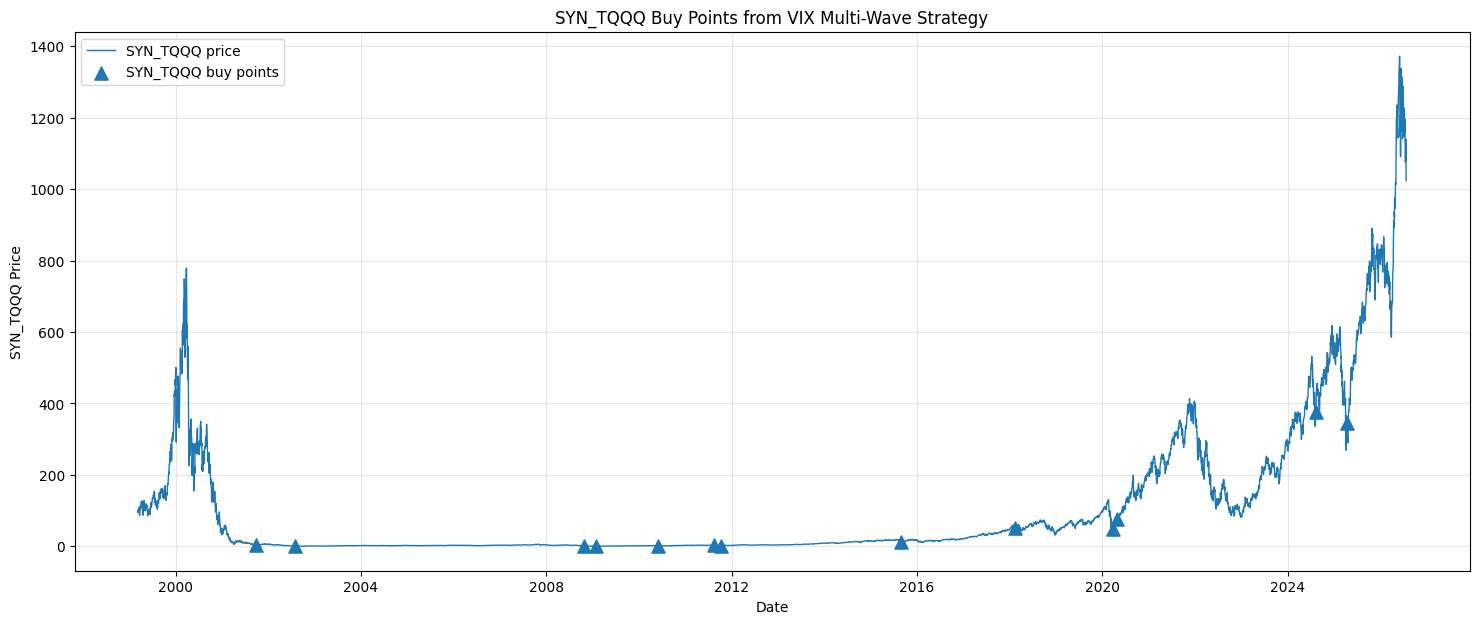

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# VIX +2σ Multi-Wave Entry Backtest
# Assets: SPY, QQQ, Synthetic TQQQ
#
# SYN_TQQQ:
# Reconstruct the series by compounding three times QQQ's daily return.
# This idealized leveraged series extends the analysis before TQQQ existed.
# =========================

# -------------------------
# Settings
# -------------------------

start_date = "1990-01-01"
window_months = 360

initial_cash = 10000
max_buys_per_event = 3
allocation_per_buy = initial_cash / max_buys_per_event

download_assets = ["SPY", "QQQ"]
test_assets = ["SPY", "QQQ", "SYN_TQQQ"]

short_wma = 5
long_wma = 10

forward_days = {
    "1M": 21,
    "3M": 63,
    "6M": 126,
    "12M": 252
}

max_buy_delay_calendar_days = 7

# Synthetic TQQQ assumptions
synthetic_tqqq_initial_value = 100
leverage = 3.0

# -------------------------
# Helper functions
# -------------------------

def wma(series, window):
    weights = np.arange(1, window + 1)
    return series.rolling(window).apply(
        lambda x: np.dot(x, weights) / weights.sum(),
        raw=True
    )

def next_available_date(index, dt):
    pos = index.searchsorted(dt)
    if pos >= len(index):
        return None
    return index[pos]

def forward_price(price_series, buy_date, days):
    pos = price_series.index.searchsorted(buy_date)
    target_pos = pos + days
    if target_pos >= len(price_series):
        return np.nan, None
    return price_series.iloc[target_pos], price_series.index[target_pos]

# -------------------------
# 1. Download VIX
# -------------------------

vix_raw = yf.download(
    "^VIX",
    start=start_date,
    end=LIVE_END_EXCLUSIVE,
    progress=False,
    auto_adjust=False,
)

if isinstance(vix_raw.columns, pd.MultiIndex):
    vix_raw.columns = vix_raw.columns.get_level_values(0)

daily = vix_raw[["High", "Close"]].dropna()
daily.columns = ["VIX_High", "VIX_Close"]

daily["WMA_5"] = wma(daily["VIX_High"], short_wma)
daily["WMA_10"] = wma(daily["VIX_High"], long_wma)

# The 5-day VIX High WMA crosses below the 10-day WMA.
# This confirms a potential peak after the volatility spike.
daily["WMA_Cross_Down"] = (
    (daily["WMA_5"] < daily["WMA_10"]) &
    (daily["WMA_5"].shift(1) >= daily["WMA_10"].shift(1))
)

# -------------------------
# 2. Monthly High VIX sigma lines
# -------------------------

monthly = pd.DataFrame()
monthly["Monthly_High_VIX"] = daily["VIX_High"].resample("ME").max()
monthly["Monthly_Close_VIX"] = daily["VIX_Close"].resample("ME").last()
monthly = monthly.dropna()

monthly["Mean_360_raw"] = monthly["Monthly_High_VIX"].rolling(window_months).mean()
monthly["Std_360_raw"] = monthly["Monthly_High_VIX"].rolling(window_months).std(ddof=0)

monthly["+1σ_raw"] = monthly["Mean_360_raw"] + monthly["Std_360_raw"]
monthly["+2σ_raw"] = monthly["Mean_360_raw"] + 2 * monthly["Std_360_raw"]

first_valid_idx = monthly["Mean_360_raw"].first_valid_index()

first_mean = monthly.loc[first_valid_idx, "Mean_360_raw"]
first_std = monthly.loc[first_valid_idx, "Std_360_raw"]

monthly["Mean_360"] = monthly["Mean_360_raw"]
monthly["Std_360"] = monthly["Std_360_raw"]
monthly["+1σ"] = monthly["+1σ_raw"]
monthly["+2σ"] = monthly["+2σ_raw"]

# Apply the first complete 360-month baseline retrospectively to early history.
pre_mask = monthly.index < first_valid_idx

monthly.loc[pre_mask, "Mean_360"] = first_mean
monthly.loc[pre_mask, "Std_360"] = first_std
monthly.loc[pre_mask, "+1σ"] = first_mean + first_std
monthly.loc[pre_mask, "+2σ"] = first_mean + 2 * first_std

monthly = monthly.dropna(subset=["+1σ", "+2σ"])

# -------------------------
# 3. Build point-in-time sigma lines for daily data
# -------------------------

daily["Month_End"] = daily.index.to_period("M").to_timestamp("M")
daily["Month_To_Date_High"] = (
    daily.groupby("Month_End")["VIX_High"].cummax()
)

# Early history keeps the same backfilled long-run reference.
# Once 360 months are available, each daily threshold uses:
#   359 completed monthly highs + the current month-to-date high.
# This prevents the final high of a month from being assigned to
# earlier dates in that same month.
daily["Mean_360"] = np.nan
daily["Std_360"] = np.nan

monthly_high_history = monthly["Monthly_High_VIX"]

for month_end, month_rows in daily.groupby("Month_End"):
    row_index = month_rows.index

    if month_end < first_valid_idx:
        daily.loc[row_index, "Mean_360"] = first_mean
        daily.loc[row_index, "Std_360"] = first_std
        continue

    prior_months = monthly_high_history.loc[
        monthly_high_history.index < month_end
    ].tail(window_months - 1)

    if len(prior_months) != window_months - 1:
        raise ValueError(
            f"Expected {window_months - 1} completed months before "
            f"{month_end.date()}, found {len(prior_months)}"
        )

    prior_sum = prior_months.sum()
    prior_sum_sq = np.square(prior_months.to_numpy()).sum()
    current_high = month_rows["Month_To_Date_High"].astype(float)

    point_in_time_mean = (
        prior_sum + current_high
    ) / window_months

    point_in_time_variance = (
        (prior_sum_sq + np.square(current_high)) / window_months
        - np.square(point_in_time_mean)
    ).clip(lower=0)

    daily.loc[row_index, "Mean_360"] = point_in_time_mean.to_numpy()
    daily.loc[row_index, "Std_360"] = np.sqrt(
        point_in_time_variance.to_numpy()
    )

daily["+1σ"] = daily["Mean_360"] + daily["Std_360"]
daily["+2σ"] = daily["Mean_360"] + 2 * daily["Std_360"]
daily = daily.dropna(subset=["+1σ", "+2σ"])

# Signals are evaluated after the daily bar is complete.
# The existing trade logic enters on the next available trading day.

daily["Above_2sigma"] = daily["VIX_High"] > daily["+2σ"]
daily["Below_2sigma"] = daily["VIX_High"] < daily["+2σ"]
daily["Below_1sigma"] = daily["VIX_High"] < daily["+1σ"]
daily["Z_score"] = (daily["VIX_High"] - daily["Mean_360"]) / daily["Std_360"]

# -------------------------
# 4. Detect multi-wave buy signals
# -------------------------

signal_records = []
event_records = []

in_event = False
event_id = 0
buy_count = 0

armed_for_buy = False
waiting_wave_end = False

below_2_count_after_buy = 0
below_1_count = 0

event_start_date = None
event_max_vix = -np.inf
event_max_vix_date = None

last_buy_signal_date = None

for dt, row in daily.iterrows():

    above2 = row["Above_2sigma"]
    below2 = row["Below_2sigma"]
    below1 = row["Below_1sigma"]
    cross_down = row["WMA_Cross_Down"]

    # Start a new VIX shock event
    if (not in_event) and above2:
        in_event = True
        event_id += 1
        buy_count = 0
        armed_for_buy = True
        waiting_wave_end = False
        below_2_count_after_buy = 0
        below_1_count = 0

        event_start_date = dt
        event_max_vix = row["VIX_High"]
        event_max_vix_date = dt
        last_buy_signal_date = None

    if not in_event:
        continue

    # Update the maximum VIX High within the event
    if row["VIX_High"] > event_max_vix:
        event_max_vix = row["VIX_High"]
        event_max_vix_date = dt

    # Track the event-exit condition
    if below1:
        below_1_count += 1
    else:
        below_1_count = 0

    # Record a buy signal
    if armed_for_buy and cross_down and buy_count < max_buys_per_event:
        buy_count += 1
        last_buy_signal_date = dt

        if row["VIX_High"] > row["+2σ"]:
            signal_type = "Above +2σ, fear-zone reversal"
        else:
            signal_type = "Below +2σ, post-shock confirmation"

        signal_records.append({
            "Event_ID": event_id,
            "Wave": buy_count,
            "Signal_Date": dt,
            "Signal_Type": signal_type,
            "VIX_High": row["VIX_High"],
            "VIX_Close": row["VIX_Close"],
            "WMA_5": row["WMA_5"],
            "WMA_10": row["WMA_10"],
            "+1σ": row["+1σ"],
            "+2σ": row["+2σ"],
            "Z_score": row["Z_score"]
        })

        armed_for_buy = False
        waiting_wave_end = True
        below_2_count_after_buy = 0

    # Determine whether the current wave has ended
    if waiting_wave_end:
        if last_buy_signal_date is not None and dt > last_buy_signal_date:
            if below2:
                below_2_count_after_buy += 1
            else:
                below_2_count_after_buy = 0

            if below_2_count_after_buy >= 5:
                waiting_wave_end = False
                below_2_count_after_buy = 0

    # Rearm the next wave after VIX breaches +2 sigma again
    if in_event and (not armed_for_buy) and (not waiting_wave_end):
        if above2 and buy_count < max_buys_per_event:
            armed_for_buy = True

    # End the event
    if below_1_count >= 10:
        event_records.append({
            "Event_ID": event_id,
            "Event_Start_Date": event_start_date,
            "Event_End_Date": dt,
            "Buy_Count": buy_count,
            "Max_VIX_Date": event_max_vix_date,
            "Max_VIX": event_max_vix
        })

        in_event = False
        armed_for_buy = False
        waiting_wave_end = False
        below_2_count_after_buy = 0
        below_1_count = 0

# Retain an event that remains open at the end of the sample
if in_event:
    event_records.append({
        "Event_ID": event_id,
        "Event_Start_Date": event_start_date,
        "Event_End_Date": daily.index[-1],
        "Buy_Count": buy_count,
        "Max_VIX_Date": event_max_vix_date,
        "Max_VIX": event_max_vix
    })

signals = pd.DataFrame(signal_records)
events = pd.DataFrame(event_records)

# -------------------------
# 5. Download SPY / QQQ
# -------------------------

asset_raw = yf.download(
    download_assets,
    start=start_date,
    end=LIVE_END_EXCLUSIVE,
    progress=False,
    auto_adjust=True
)

if isinstance(asset_raw.columns, pd.MultiIndex):
    asset_close = asset_raw["Close"].dropna(how="all")
else:
    asset_close = asset_raw[["Close"]].copy()
    asset_close.columns = download_assets

# -------------------------
# 6. Create Synthetic TQQQ
# -------------------------

qqq_price = asset_close["QQQ"].dropna()
qqq_ret = qqq_price.pct_change()

synthetic_tqqq = pd.Series(index=qqq_price.index, dtype=float)
synthetic_tqqq.iloc[0] = synthetic_tqqq_initial_value

for i in range(1, len(qqq_price)):
    r = qqq_ret.iloc[i]
    synthetic_tqqq.iloc[i] = synthetic_tqqq.iloc[i - 1] * (1 + leverage * r)

asset_close["SYN_TQQQ"] = synthetic_tqqq

# -------------------------
# 7. Evaluate trades
# -------------------------

trade_records = []
skipped_records = []

for _, sig in signals.iterrows():

    signal_date = sig["Signal_Date"]
    intended_buy_start = signal_date + pd.Timedelta(days=1)

    for asset in test_assets:

        price_series = asset_close[asset].dropna()
        first_asset_date = price_series.index[0]

        # Skip the trade when the ETF or synthetic series is not yet available.
        if intended_buy_start < first_asset_date:
            skipped_records.append({
                "Asset": asset,
                "Event_ID": sig["Event_ID"],
                "Wave": sig["Wave"],
                "Signal_Date": signal_date.date(),
                "Reason": "Asset not available yet",
                "First_Available_Date": first_asset_date.date()
            })
            continue

        buy_date = next_available_date(price_series.index, intended_buy_start)

        if buy_date is None:
            skipped_records.append({
                "Asset": asset,
                "Event_ID": sig["Event_ID"],
                "Wave": sig["Wave"],
                "Signal_Date": signal_date.date(),
                "Reason": "No available buy date",
                "First_Available_Date": first_asset_date.date()
            })
            continue

        delay_days = (buy_date - signal_date).days

        if delay_days > max_buy_delay_calendar_days:
            skipped_records.append({
                "Asset": asset,
                "Event_ID": sig["Event_ID"],
                "Wave": sig["Wave"],
                "Signal_Date": signal_date.date(),
                "Reason": f"Buy date too far from signal, {delay_days} calendar days",
                "First_Available_Date": first_asset_date.date()
            })
            continue

        buy_price = price_series.loc[buy_date]
        shares = allocation_per_buy / buy_price

        record = {
            "Asset": asset,
            "Event_ID": sig["Event_ID"],
            "Wave": sig["Wave"],
            "Signal_Date": signal_date.date(),
            "Signal_Type": sig["Signal_Type"],
            "Buy_Date": buy_date.date(),
            "Buy_Price": buy_price,
            "Allocation": allocation_per_buy,
            "Shares": shares,
            "VIX_High_At_Signal": sig["VIX_High"],
            "Signal_+2σ": sig["+2σ"],
            "Signal_Z": sig["Z_score"]
        }

        for label, days in forward_days.items():
            future_price, future_date = forward_price(price_series, buy_date, days)

            record[f"{label}_Date"] = future_date.date() if future_date is not None else None
            record[f"{label}_Price"] = future_price
            record[f"{label}_Return_%"] = (
                (future_price / buy_price - 1) * 100
                if pd.notna(future_price)
                else np.nan
            )
            record[f"{label}_Profit_$"] = (
                shares * (future_price - buy_price)
                if pd.notna(future_price)
                else np.nan
            )

        trade_records.append(record)

trades = pd.DataFrame(trade_records)
skipped = pd.DataFrame(skipped_records)

# -------------------------
# 8. Summary
# -------------------------

summary = (
    trades
    .groupby("Asset")
    .agg(
        Trades=("Buy_Date", "count"),
        Avg_1M_Return=("1M_Return_%", "mean"),
        Avg_3M_Return=("3M_Return_%", "mean"),
        Avg_6M_Return=("6M_Return_%", "mean"),
        Avg_12M_Return=("12M_Return_%", "mean"),
        WinRate_1M=("1M_Return_%", lambda x: (x > 0).mean() * 100),
        WinRate_3M=("3M_Return_%", lambda x: (x > 0).mean() * 100),
        WinRate_6M=("6M_Return_%", lambda x: (x > 0).mean() * 100),
        WinRate_12M=("12M_Return_%", lambda x: (x > 0).mean() * 100),
    )
    .reset_index()
)

summary_by_signal_type = (
    trades
    .groupby(["Asset", "Signal_Type"])
    .agg(
        Trades=("Buy_Date", "count"),
        Avg_1M_Return=("1M_Return_%", "mean"),
        Avg_3M_Return=("3M_Return_%", "mean"),
        Avg_6M_Return=("6M_Return_%", "mean"),
        Avg_12M_Return=("12M_Return_%", "mean"),
        WinRate_12M=("12M_Return_%", lambda x: (x > 0).mean() * 100),
    )
    .reset_index()
)

event_asset_summary = (
    trades
    .groupby(["Asset", "Event_ID"])
    .agg(
        Buy_Count=("Buy_Date", "count"),
        Total_Allocation=("Allocation", "sum"),
        Avg_Buy_Price=("Buy_Price", "mean"),
        Avg_1M_Return=("1M_Return_%", "mean"),
        Avg_3M_Return=("3M_Return_%", "mean"),
        Avg_6M_Return=("6M_Return_%", "mean"),
        Avg_12M_Return=("12M_Return_%", "mean")
    )
    .reset_index()
)

# -------------------------
# 9. Print results
# -------------------------

print("===== VIX Data Period =====")
print("Daily start:", daily.index[0].date())
print("Daily end  :", daily.index[-1].date())
print("First valid 360M baseline:", first_valid_idx.date())
print("Initial +2σ:", first_mean + 2 * first_std)

print("\n===== VIX Crisis Events =====")
print(events)

print("\n===== Buy Signals =====")
print(signals[[
    "Event_ID", "Wave", "Signal_Date", "Signal_Type",
    "VIX_High", "WMA_5", "WMA_10", "+2σ", "Z_score"
]])

print("\n===== Skipped Trades =====")
print(skipped)

print("\n===== Trade Results: SPY, QQQ, SYN_TQQQ =====")
print(trades)

print("\n===== Summary by Asset =====")
print(summary)

print("\n===== Summary by Signal Type =====")
print(summary_by_signal_type)

print("\n===== Event Asset Summary =====")
print(event_asset_summary)

# Save CSV outputs
signals.to_csv("vix_multiwave_buy_signals_tqqq.csv", index=False)
events.to_csv("vix_crisis_events_tqqq.csv", index=False)
trades.to_csv("vix_multiwave_spy_qqq_syntqqq_trade_results.csv", index=False)
skipped.to_csv("vix_multiwave_skipped_trades_tqqq.csv", index=False)
summary.to_csv("vix_multiwave_spy_qqq_syntqqq_summary.csv", index=False)
summary_by_signal_type.to_csv("vix_multiwave_summary_by_signal_type_tqqq.csv", index=False)
event_asset_summary.to_csv("vix_multiwave_event_asset_summary_tqqq.csv", index=False)

print("\nSaved files:")
print("vix_multiwave_buy_signals_tqqq.csv")
print("vix_crisis_events_tqqq.csv")
print("vix_multiwave_spy_qqq_syntqqq_trade_results.csv")
print("vix_multiwave_skipped_trades_tqqq.csv")
print("vix_multiwave_spy_qqq_syntqqq_summary.csv")
print("vix_multiwave_summary_by_signal_type_tqqq.csv")
print("vix_multiwave_event_asset_summary_tqqq.csv")

# -------------------------
# 10. Chart: VIX and signals
# -------------------------

plt.figure(figsize=(18, 8))

plt.plot(daily.index, daily["VIX_High"], label="Daily VIX High", linewidth=0.8)
plt.plot(daily.index, daily["+2σ"], label="+2σ", linestyle=":", linewidth=2)
plt.plot(daily.index, daily["+1σ"], label="+1σ", linestyle="--", linewidth=1.5)

if len(signals) > 0:
    plt.scatter(
        signals["Signal_Date"],
        signals["VIX_High"],
        label="Buy Signal",
        s=90,
        marker="v",
        zorder=5
    )

plt.title("VIX Daily High with +1σ/+2σ and Multi-Wave Buy Signals")
plt.xlabel("Date")
plt.ylabel("VIX")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# -------------------------
# 11. Chart: Asset buy points
# -------------------------

for asset in test_assets:
    price_series = asset_close[asset].dropna()
    asset_trades = trades[trades["Asset"] == asset].copy()

    plt.figure(figsize=(18, 7))
    plt.plot(price_series.index, price_series, label=f"{asset} price", linewidth=1)

    if len(asset_trades) > 0:
        buy_dates = pd.to_datetime(asset_trades["Buy_Date"])
        valid_buy_dates = [d for d in buy_dates if d in price_series.index]

        plt.scatter(
            valid_buy_dates,
            price_series.loc[valid_buy_dates],
            label=f"{asset} buy points",
            s=90,
            marker="^",
            zorder=5
        )

    plt.title(f"{asset} Buy Points from VIX Multi-Wave Strategy")
    plt.xlabel("Date")
    plt.ylabel(f"{asset} Price")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()